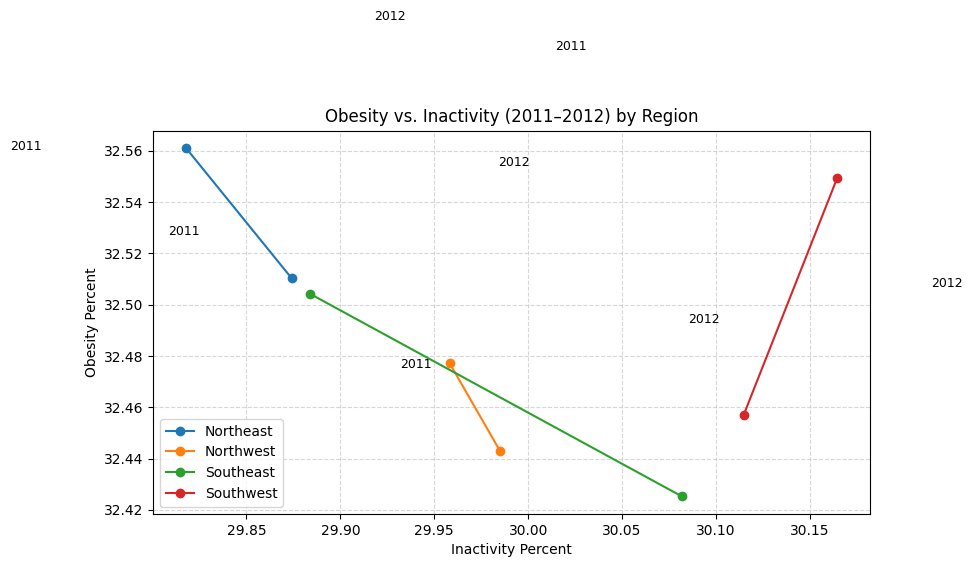

In [22]:
# BRFSS Obesity and Physical Inactivity Analysis (2011–2012)
import pandas as pd
import matplotlib.pyplot as plt

# Load and clean data
df = pd.read_csv("/Users/jahnavidhingra/Desktop/BRFSS_dataset.csv")
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()
df = df.rename(columns={
    'noleisureactivitypercent': 'inactivity_percent',
    'obesitypercent': 'obesity_percent'
})
df = df.dropna(subset=['year', 'state', 'inactivity_percent', 'obesity_percent'])

# Define regions
northeast = ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut',
             'New York', 'New Jersey', 'Pennsylvania']

southeast = ['Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia', 'Kentucky',
             'Tennessee', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Alabama', 'Mississippi']

southwest = ['Arizona', 'New Mexico', 'Oklahoma', 'Texas']

northwest = ['Washington', 'Oregon', 'Idaho', 'Montana', 'Wyoming', 'Alaska']

# Region assignment
def get_region(state):
    if state in northeast:
        return 'Northeast'
    elif state in southeast:
        return 'Southeast'
    elif state in southwest:
        return 'Southwest'
    elif state in northwest:
        return 'Northwest'
    else:
        return None

df['region'] = df['state'].apply(get_region)
df = df[df['region'].notna()]
df_years = df[df['year'].isin([2011, 2012])]

# Group and aggregate
df_grouped = df_years.groupby(['region', 'year'])[['inactivity_percent', 'obesity_percent']].mean().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
for region in df_grouped['region'].unique():
    subset = df_grouped[df_grouped['region'] == region].sort_values('year')
    plt.plot(subset['inactivity_percent'], subset['obesity_percent'], marker='o', label=region)
        # Label only start (2011) and end (2012) clearly
    start = subset[subset['year'] == 2011].iloc[0]
    end = subset[subset['year'] == 2012].iloc[0]
    plt.text(start['inactivity_percent'] - 0.15, start['obesity_percent'] + 0.05, '2011', fontsize=9)
    plt.text(end['inactivity_percent'] + 0.1, end['obesity_percent'] + 0.05, '2012', fontsize=9)


plt.title("Obesity vs. Inactivity (2011–2012) by Region")
plt.xlabel("Inactivity Percent")
plt.ylabel("Obesity Percent")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()



